# Model Evaluation — full report

Loads the artifacts written by `scripts/train_clean.py` and runs a comprehensive evaluation on the held-out test set. **Touch this notebook only after training is final** — every section here uses the test split.

Sections:

1. Load artifacts + splits
2. Status classifier — global metrics with bootstrap CIs
3. Per-class breakdown + confusion matrix
4. Per-vertical breakdown
5. Per-cluster breakdown
6. Calibration: reliability diagram
7. ROC curves (one-vs-rest, per class)
8. Health Score validation
9. Fatigue 4-bucket model evaluation
10. Action-tier (Pause / Watch / Maintain / Scale) decision quality
11. Failure analysis — hardest examples
12. Final report card

## 1 — Load artifacts and splits

In [1]:
import warnings, json, pickle
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.metrics import (f1_score, classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, log_loss)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

REPO = Path('..').resolve()
# Prefer the --final artifacts (trained on train ∪ val); fall back to clean/
FINAL = REPO / 'outputs/models/final'
CLEAN = REPO / 'outputs/models/clean'
ARTIFACTS = FINAL if (FINAL / 'meta.pkl').exists() else CLEAN
print(f'using artifacts from: {ARTIFACTS.relative_to(REPO)}')

with open(ARTIFACTS / 'meta.pkl', 'rb') as f: meta = pickle.load(f)
FEATS, CAT, NUM = meta['feats'], meta['cat_cols'], meta['num_cols']
encoders, y_enc = meta['encoders'], meta['y_encoder']
CLASS_NAMES = meta['class_names']

# Load 5 XGB seeds + the rest
xgb_models = []
for i in range(len(meta['bag_seeds'])):
    m = xgb.XGBClassifier(); m.load_model(str(ARTIFACTS / f'xgb_seed{i}.json'))
    xgb_models.append(m)
with open(ARTIFACTS / 'lgb.pkl', 'rb') as f: lgb_model = pickle.load(f)
with open(ARTIFACTS / 'hgb.pkl', 'rb') as f: hgb_model = pickle.load(f)
with open(ARTIFACTS / 'logreg.pkl', 'rb') as f: lr_model = pickle.load(f)
cb_model = CatBoostClassifier(); cb_model.load_model(str(ARTIFACTS / 'catboost.cbm'))
with open(ARTIFACTS / 'fatigue_4bucket.pkl', 'rb') as f:
    fat_pack = pickle.load(f); fat_model, fy_enc = fat_pack['model'], fat_pack['encoder']

# Load splits
train = pd.read_parquet(REPO / 'outputs/splits/train.parquet')
val   = pd.read_parquet(REPO / 'outputs/splits/val.parquet')
test  = pd.read_parquet(REPO / 'outputs/splits/test.parquet')

def encode_X(df):
    X = df[FEATS].copy()
    for c, le in encoders.items(): X[c] = le.transform(df[c].astype(str))
    for c in FEATS: X[c] = pd.to_numeric(X[c], errors='coerce').astype(np.float32)
    return X
def cb_input(df):
    out = df[FEATS].copy()
    for c in CAT: out[c] = df[c].astype(str)
    for c in NUM: out[c] = pd.to_numeric(df[c], errors='coerce').astype(float)
    return out

X_va, X_te = encode_X(val), encode_X(test)
y_va, y_te = y_enc.transform(val['creative_status']), y_enc.transform(test['creative_status'])

def ensemble_proba(X, df_cb, df_lr):
    """Soft-vote ensemble — RAW probabilities (no temperature scaling)."""
    p1 = np.mean([m.predict_proba(X) for m in xgb_models], axis=0)
    p2 = lgb_model.predict_proba(X)
    p3 = cb_model.predict_proba(df_cb)
    p4 = hgb_model.predict_proba(X)
    p5 = lr_model.predict_proba(df_lr[FEATS])
    return (p1 + p2 + p3 + p4 + p5) / 5.0

P_va = ensemble_proba(X_va, cb_input(val),  val)
P_te = ensemble_proba(X_te, cb_input(test), test)
print(f'loaded {len(xgb_models)} XGB seeds + LGB + CatBoost + HGB + LR + 4-bucket fatigue model')
print(f'val P shape: {P_va.shape}  test P shape: {P_te.shape}')
print('temperature scaling: disabled (raw probabilities)')

using artifacts from: outputs/models/final


loaded 5 XGB seeds + LGB + CatBoost + HGB + LR + 4-bucket fatigue model
val P shape: (143, 4)  test P shape: (216, 4)
temperature scaling: disabled (raw probabilities)


## 2 — Global metrics with bootstrap CIs

With n=216 test rows and severe imbalance, point estimates are not enough. We bootstrap (1000 resamples) to put 95% CIs on every metric.

In [2]:
rng = np.random.default_rng(42)

def bootstrap_ci(metric_fn, *args, n_iter=1000, alpha=0.05):
    n = len(args[0])
    samples = []
    for _ in range(n_iter):
        idx = rng.integers(0, n, size=n)
        try: samples.append(metric_fn(*[a[idx] for a in args]))
        except Exception: pass
    samples = np.array(samples)
    return float(np.mean(samples)), tuple(np.quantile(samples, [alpha/2, 1-alpha/2]))

def macro_f1(y, p): return f1_score(y, p, average='macro', zero_division=0)
def weighted_f1(y, p): return f1_score(y, p, average='weighted', zero_division=0)
def accuracy(y, p): return (y == p).mean()

pred_te = P_te.argmax(1)

rows = []
for name, fn in [('macro-F1', macro_f1), ('weighted-F1', weighted_f1), ('accuracy', accuracy)]:
    point, (lo, hi) = bootstrap_ci(fn, y_te, pred_te)
    rows.append({'metric': name, 'point': round(point, 4), '95% CI': f'[{lo:.4f}, {hi:.4f}]'})

# Log-loss + ECE on the proba
def ece(proba, y, n_bins=10):
    conf, pred = proba.max(1), proba.argmax(1)
    correct = (pred == y).astype(float)
    bins = np.linspace(0, 1, n_bins+1)
    e = 0.0
    for i in range(n_bins):
        m = (conf >= bins[i]) & (conf < bins[i+1])
        if m.sum() == 0: continue
        e += (m.sum() / len(y)) * abs(correct[m].mean() - conf[m].mean())
    return e

rows.append({'metric': 'log-loss',
             'point': round(log_loss(y_te, np.clip(P_te, 1e-9, 1-1e-9), labels=range(len(CLASS_NAMES))), 4),
             '95% CI': '—'})
rows.append({'metric': 'ECE', 'point': round(ece(P_te, y_te), 4), '95% CI': '—'})
display(pd.DataFrame(rows))

,metric,point,95% CI
0,macro-F1,0.6698,"[0.5680, 0.7664]"
1,weighted-F1,0.7797,"[0.7258, 0.8306]"
2,accuracy,0.7731,"[0.7176, 0.8287]"
3,log-loss,0.5767,—
4,ECE,0.0731,—


## 3 — Per-class breakdown + confusion matrix

,class,n_test,F1,95% CI
0,fatigued,35,0.630,"[0.487, 0.747]"
1,stable,154,0.841,"[0.798, 0.882]"
2,top_performer,11,0.585,"[0.286, 0.813]"
3,underperformer,16,0.625,"[0.424, 0.800]"


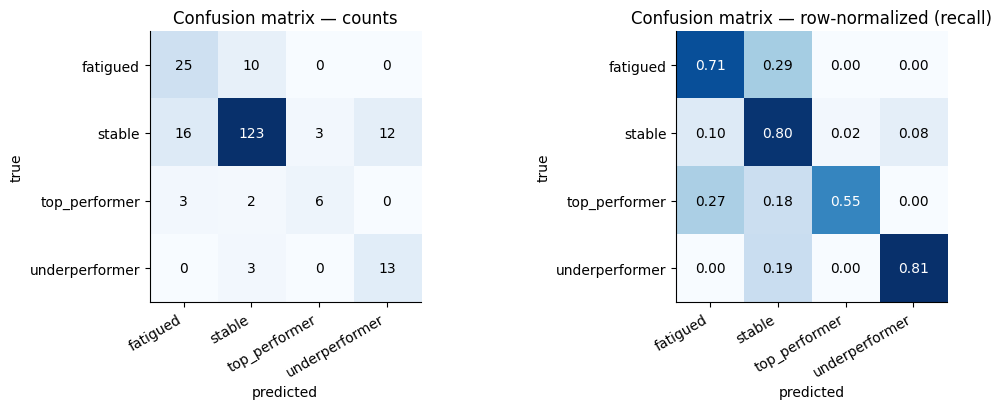

In [3]:
# Per-class F1 with bootstrap CIs
per_class = []
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    def f1_cls(y, p, cls=cls_idx):
        return f1_score(y == cls, p == cls, zero_division=0)
    point, (lo, hi) = bootstrap_ci(f1_cls, y_te, pred_te)
    n = int((y_te == cls_idx).sum())
    per_class.append({'class': cls_name, 'n_test': n, 'F1': round(point, 3),
                       '95% CI': f'[{lo:.3f}, {hi:.3f}]'})
display(pd.DataFrame(per_class))

cm = confusion_matrix(y_te, pred_te)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, mat, title, fmt in [(axes[0], cm, 'counts', 'd'),
                              (axes[1], cm_norm, 'row-normalized (recall)', '.2f')]:
    im = ax.imshow(mat, cmap='Blues', vmin=0)
    ax.set_xticks(range(len(CLASS_NAMES))); ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
    ax.set_yticklabels(CLASS_NAMES)
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            v = mat[i, j]
            ax.text(j, i, format(v, fmt), ha='center', va='center',
                    color='white' if v > mat.max()/2 else 'black', fontsize=10)
    ax.set_title(f'Confusion matrix — {title}')
    ax.set_xlabel('predicted'); ax.set_ylabel('true')
plt.tight_layout(); plt.show()

## 4 — Per-vertical breakdown

Where does the model work best, and where does it struggle?

,vertical,n,macro-F1,accuracy
5,travel,36,0.774,0.778
3,food_delivery,36,0.677,0.694
2,fintech,36,0.662,0.972
1,entertainment,36,0.597,0.778
0,ecommerce,36,0.557,0.833
4,gaming,36,0.514,0.583


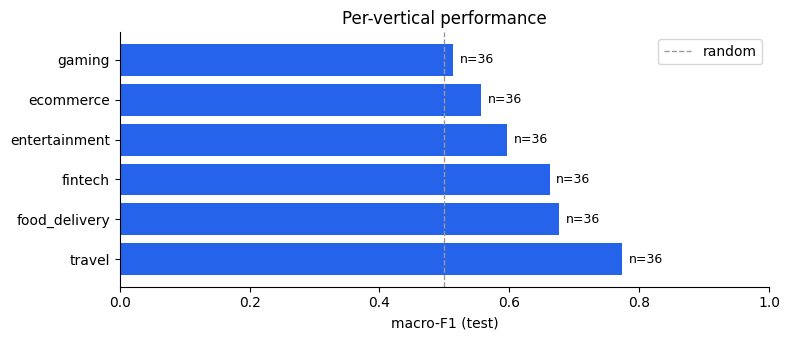

In [4]:
vert_rows = []
for vert in sorted(test['vertical'].unique()):
    mask = test['vertical'] == vert
    if mask.sum() < 2: continue
    f1 = f1_score(y_te[mask], pred_te[mask], average='macro', zero_division=0)
    acc = (y_te[mask] == pred_te[mask]).mean()
    vert_rows.append({'vertical': vert, 'n': int(mask.sum()),
                       'macro-F1': round(f1, 3), 'accuracy': round(acc, 3)})
per_vert = pd.DataFrame(vert_rows).sort_values('macro-F1', ascending=False)
display(per_vert)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(per_vert['vertical'], per_vert['macro-F1'], color='#2563eb')
ax.axvline(0.5, color='#999', ls='--', lw=1, label='random')
ax.set_xlim(0, 1); ax.set_xlabel('macro-F1 (test)')
ax.set_title('Per-vertical performance')
for i, row in per_vert.reset_index(drop=True).iterrows():
    ax.text(row['macro-F1'] + 0.01, i, f'n={row["n"]}', va='center', fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()

## 5 — Per-cluster breakdown

The KMeans-24 clusters from `build_clean_dataset.py` are visual+behavioral genome neighborhoods. Does the model handle some clusters more reliably than others?

In [5]:
clu_rows = []
for c in sorted(test['cluster'].unique()):
    mask = test['cluster'] == c
    if mask.sum() < 3: continue
    f1 = f1_score(y_te[mask], pred_te[mask], average='macro', zero_division=0)
    acc = (y_te[mask] == pred_te[mask]).mean()
    top_v = test.loc[mask, 'vertical'].mode().iloc[0]
    top_f = test.loc[mask, 'format'].mode().iloc[0]
    clu_rows.append({'cluster': int(c), 'n': int(mask.sum()),
                      'top_vertical': top_v, 'top_format': top_f,
                      'macro-F1': round(f1, 3), 'accuracy': round(acc, 3)})
per_clu = pd.DataFrame(clu_rows).sort_values('macro-F1', ascending=False)
display(per_clu.head(15))
print(f'\n{len(per_clu)} clusters with n≥3 in test')
print(f'best  cluster F1: {per_clu["macro-F1"].max():.3f}')
print(f'worst cluster F1: {per_clu["macro-F1"].min():.3f}')
print(f'median cluster F1: {per_clu["macro-F1"].median():.3f}')

,cluster,n,top_vertical,top_format,macro-F1,accuracy
16,16,6,fintech,native,1.000,1.000
11,11,10,fintech,interstitial,0.867,0.900
19,19,10,food_delivery,native,0.867,0.900
6,6,5,gaming,interstitial,0.800,0.800
21,21,4,gaming,rewarded_video,0.733,0.750
4,4,4,entertainment,interstitial,0.733,0.750
9,9,14,fintech,native,0.708,0.857
8,8,12,travel,native,0.700,0.833
10,10,11,entertainment,interstitial,0.694,0.818
3,3,10,travel,interstitial,0.687,0.700



24 clusters with n≥3 in test
best  cluster F1: 1.000
worst cluster F1: 0.133
median cluster F1: 0.622


## 6 — Reliability diagram (raw, uncalibrated)

Are the model's confidence levels meaningful out of the box? A perfectly calibrated model lies on the diagonal. Bars below the diagonal = overconfident; above = underconfident. We do NOT apply temperature scaling — the chart shows the model's raw behavior.

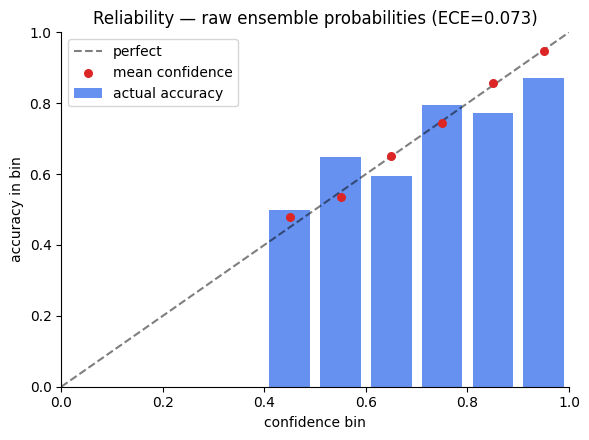

In [6]:
def reliability(proba, y, n_bins=10):
    conf, pred = proba.max(1), proba.argmax(1)
    correct = (pred == y).astype(float)
    bins = np.linspace(0, 1, n_bins+1)
    centers = (bins[:-1] + bins[1:]) / 2
    accs, confs, sizes = [], [], []
    for i in range(n_bins):
        m = (conf >= bins[i]) & (conf < bins[i+1])
        if m.sum() == 0: accs.append(np.nan); confs.append(np.nan); sizes.append(0)
        else: accs.append(correct[m].mean()); confs.append(conf[m].mean()); sizes.append(m.sum())
    return centers, np.array(accs), np.array(confs), np.array(sizes)

fig, ax = plt.subplots(figsize=(6, 4.5))
centers, accs, confs, sizes = reliability(P_te, y_te)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect')
ax.bar(centers, accs, width=0.08, color='#2563eb', alpha=0.7, label='actual accuracy')
ax.scatter(centers, confs, color='#dc2626', s=30, label='mean confidence', zorder=5)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('confidence bin'); ax.set_ylabel('accuracy in bin')
ax.set_title(f'Reliability — raw ensemble probabilities (ECE={ece(P_te, y_te):.3f})')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

## 7 — One-vs-rest ROC curves

For each class, plot the ROC: how well does the predicted P(class=k) separate class k from everything else?

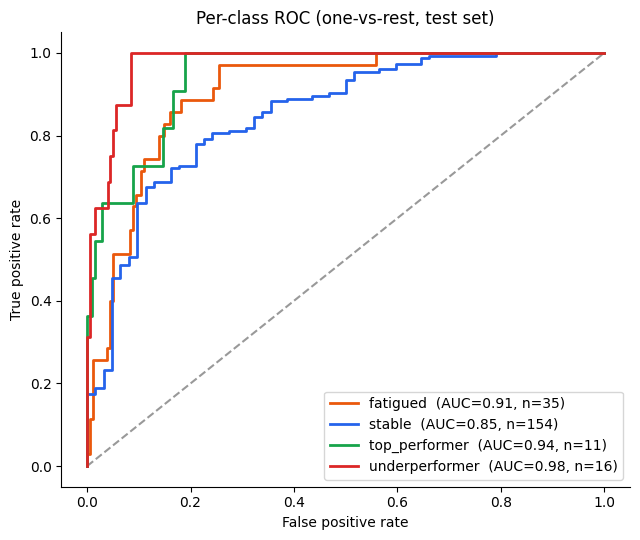


AUCs: {'fatigued': 0.905, 'stable': 0.852, 'top_performer': 0.941, 'underperformer': 0.975}


In [7]:
colors = {'top_performer': '#16a34a', 'stable': '#2563eb',
           'fatigued': '#ea580c', 'underperformer': '#dc2626'}

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot([0,1], [0,1], 'k--', alpha=0.4)
aucs = {}
for k, name in enumerate(CLASS_NAMES):
    y_bin = (y_te == k).astype(int)
    if y_bin.sum() == 0 or y_bin.sum() == len(y_bin): continue
    fpr, tpr, _ = roc_curve(y_bin, P_te[:, k])
    auc = roc_auc_score(y_bin, P_te[:, k])
    aucs[name] = auc
    ax.plot(fpr, tpr, color=colors.get(name, 'gray'),
            label=f'{name}  (AUC={auc:.2f}, n={y_bin.sum()})', lw=2)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('Per-class ROC (one-vs-rest, test set)')
ax.legend(); plt.tight_layout(); plt.show()

print('\nAUCs:', {k: round(v, 3) for k, v in aucs.items()})

## 8 — Health Score validation

The score combines calibrated P(top) + early-CTR percentile + early-ROAS percentile + anti-fatigue. Two questions: (a) does it correlate with the true status, (b) does its action-mapping make sensible recommendations?

Spearman(health_score, status_rank) = 0.452  (p=2.69e-12)


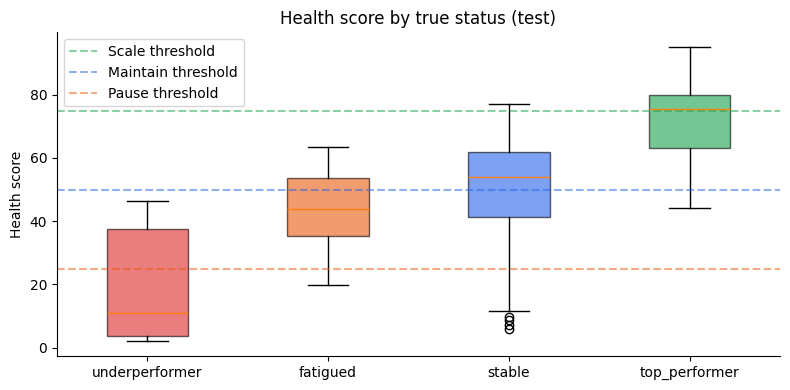


Health score by true status:
                mean  median  count
status                             
fatigued        43.6    43.9     35
stable          50.5    54.1    154
top_performer   71.9    75.4     11
underperformer  17.6    10.8     16


In [8]:
from scipy.stats import spearmanr

def percentile_within_vertical(values, verticals):
    s = pd.Series(values).fillna(0)
    return s.groupby(verticals).rank(pct=True).values

def health_score(df, P_cal, weights=(0.35, 0.25, 0.20, 0.20)):
    cls = {n: i for i, n in enumerate(CLASS_NAMES)}
    perf = P_cal[:, cls['top_performer']] + 0.5 * P_cal[:, cls['stable']]
    perf = (perf - perf.min()) / (perf.max() - perf.min() + 1e-9)
    ctr_pct = percentile_within_vertical(df['early_ctr'].values, df['vertical'].values)
    roas = (df['early_revenue'] / df['early_spend'].replace(0, np.nan)).fillna(0).values
    roas_pct = percentile_within_vertical(roas, df['vertical'].values)
    af = 1 - P_cal[:, cls['fatigued']] - P_cal[:, cls['underperformer']]
    af = (af - af.min()) / (af.max() - af.min() + 1e-9)
    w = np.array(weights)
    return 100 * (w[0]*perf + w[1]*ctr_pct + w[2]*roas_pct + w[3]*af)

hs = health_score(test, P_te)
status_rank = {'top_performer': 4, 'stable': 3, 'fatigued': 2, 'underperformer': 1}
r, p = spearmanr(hs, test['creative_status'].map(status_rank))
print(f'Spearman(health_score, status_rank) = {r:.3f}  (p={p:.2e})')

by_status = pd.DataFrame({'health_score': hs, 'status': test['creative_status'].values})

fig, ax = plt.subplots(figsize=(8, 4))
order = ['underperformer', 'fatigued', 'stable', 'top_performer']
data = [by_status.loc[by_status['status']==s, 'health_score'].values for s in order]
bp = ax.boxplot(data, labels=order, patch_artist=True)
for patch, s in zip(bp['boxes'], order):
    patch.set_facecolor(colors.get(s, '#999'))
    patch.set_alpha(0.6)
ax.set_ylabel('Health score'); ax.set_title('Health score by true status (test)')
ax.axhline(75, ls='--', color='#16a34a', alpha=0.5, label='Scale threshold')
ax.axhline(50, ls='--', color='#2563eb', alpha=0.5, label='Maintain threshold')
ax.axhline(25, ls='--', color='#ea580c', alpha=0.5, label='Pause threshold')
ax.legend(); plt.tight_layout(); plt.show()

print('\nHealth score by true status:')
print(by_status.groupby('status')['health_score'].agg(['mean','median','count']).round(1))

## 9 — Fatigue 4-bucket model evaluation

Model: `LightGBM(num_leaves=15, class_weight='balanced')` predicting Never / Late / Standard / Early fatigue. Re-merge target from raw summary.

Fatigue 4-bucket test macro-F1: 0.428
              precision    recall  f1-score   support

       early       0.46      0.43      0.44        14
        late       0.00      0.00      0.00         4
       never       0.91      0.93      0.92       181
    standard       0.42      0.29      0.34        17

    accuracy                           0.83       216
   macro avg       0.45      0.41      0.43       216
weighted avg       0.82      0.83      0.83       216



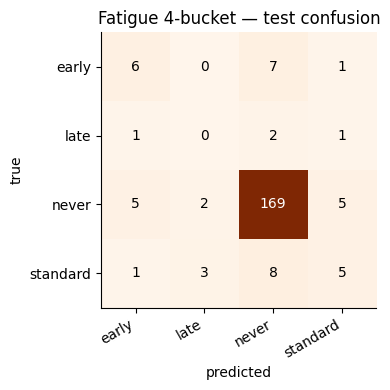

In [9]:
raw = pd.read_csv(REPO.parent / 'creative_summary.csv', usecols=['creative_id','fatigue_day'])
def fatigue_bucket(d):
    if pd.isna(d): return 'never'
    if d >= 14:    return 'late'
    if d >= 12:    return 'standard'
    return 'early'
raw['fatigue_bucket'] = raw['fatigue_day'].apply(fatigue_bucket)

test_f = test.merge(raw[['creative_id','fatigue_bucket']], on='creative_id', how='left')
y_f_te = fy_enc.transform(test_f['fatigue_bucket'])
p_f_te = fat_model.predict_proba(X_te)
pred_f_te = p_f_te.argmax(1)

print(f'Fatigue 4-bucket test macro-F1: {f1_score(y_f_te, pred_f_te, average="macro"):.3f}')
print(classification_report(y_f_te, pred_f_te, target_names=fy_enc.classes_, zero_division=0))

cm_f = confusion_matrix(y_f_te, pred_f_te)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_f, cmap='Oranges')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(fy_enc.classes_, rotation=30, ha='right')
ax.set_yticklabels(fy_enc.classes_)
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm_f[i, j], ha='center', va='center',
                color='white' if cm_f[i, j] > cm_f.max()/2 else 'black')
ax.set_title('Fatigue 4-bucket — test confusion'); ax.set_xlabel('predicted'); ax.set_ylabel('true')
plt.tight_layout(); plt.show()

## 10 — Action-tier decision quality

Map health_score → action: `≥75 → Scale`, `50–75 → Maintain`, `25–50 → Watch`, `<25 → Pause/Pivot`. Then check: of all creatives recommended *Scale*, what fraction are actually top_performers? Of all recommended *Pause*, what fraction are actually under/fatigued? This is the metric a marketer cares about.

In [10]:
def action(s):
    if s >= 75: return 'Scale'
    if s >= 50: return 'Maintain'
    if s >= 25: return 'Watch'
    return 'Pause/Pivot'

actions = pd.Series(hs).apply(action)
true_status = test['creative_status'].values

print('Action × true_status crosstab (test):')
crosstab = pd.crosstab(actions, true_status, margins=True, margins_name='total')
display(crosstab)

# Action-quality metrics
def action_quality():
    rows = []
    rows.append({
        'action': 'Scale (≥75)',
        'n_recommended': (actions == 'Scale').sum(),
        'precision_for_top_performer': round(((actions == 'Scale') & (true_status == 'top_performer')).sum() / max((actions == 'Scale').sum(), 1), 3),
        'recall_of_top_performers': round(((actions == 'Scale') & (true_status == 'top_performer')).sum() / max((true_status == 'top_performer').sum(), 1), 3),
    })
    bad = np.isin(true_status, ['underperformer', 'fatigued'])
    pause = (actions == 'Pause/Pivot')
    rows.append({
        'action': 'Pause/Pivot (<25)',
        'n_recommended': pause.sum(),
        'precision_for_bad': round((pause & bad).sum() / max(pause.sum(), 1), 3),
        'recall_of_bad': round((pause & bad).sum() / max(bad.sum(), 1), 3),
    })
    return pd.DataFrame(rows)
display(action_quality())

Action × true_status crosstab (test):


col_0,fatigued,stable,top_performer,underperformer,total
row_0,,,,,
Maintain,12,87,3,0,102
Pause/Pivot,4,10,0,11,25
Scale,0,1,6,0,7
Watch,19,56,2,5,82
total,35,154,11,16,216


,action,n_recommended,precision_for_top_performer,recall_of_top_performers,precision_for_bad,recall_of_bad
0,Scale (≥75),7,0.857,0.545,NaN,NaN
1,Pause/Pivot (<25),25,NaN,NaN,0.6,0.294


## 11 — Failure analysis: top-10 hardest examples

Where does the model lose the most log-likelihood? These are the test rows worth a manual look.

In [11]:
per_row_ll = -np.log(np.clip(P_te[np.arange(len(y_te)), y_te], 1e-9, 1.0))
hardest_idx = np.argsort(-per_row_ll)[:10]

hard = test.iloc[hardest_idx][['creative_id','vertical','format','dominant_color',
                                'has_gameplay','has_ugc_style','early_ctr','early_clicks',
                                'creative_status']].copy()
hard['predicted'] = [CLASS_NAMES[i] for i in pred_te[hardest_idx]]
hard['confidence'] = P_te[hardest_idx].max(1).round(2)
hard['neg_log_lik'] = per_row_ll[hardest_idx].round(2)
display(hard)

print('\nObserve: most hardest examples are misclassified rare-class creatives where the')
print('model output high confidence in a wrong class. These are the ones a counterfactual')
print('explanation (§11 of 04_models.ipynb) is most actionable for.')

,creative_id,vertical,format,dominant_color,has_gameplay,has_ugc_style,early_ctr,early_clicks,creative_status,predicted,confidence,neg_log_lik
158,500806,fintech,interstitial,white,0,1,0.008796,4620,top_performer,stable,0.95,4.32
53,500371,ecommerce,interstitial,blue,0,1,0.012846,4142,top_performer,stable,0.92,3.76
198,500996,food_delivery,banner,orange,0,1,0.006088,24644,stable,underperformer,0.98,3.72
15,500147,gaming,rewarded_video,lime,1,0,0.017879,16263,top_performer,fatigued,0.96,3.63
184,500886,travel,native,lime,0,1,0.009238,11431,fatigued,stable,0.95,3.27
14,500146,gaming,rewarded_video,orange,0,0,0.016335,13654,stable,fatigued,0.92,3.18
5,500029,food_delivery,banner,purple,0,0,0.007119,15294,stable,underperformer,0.95,3.01
87,500543,gaming,rewarded_video,lime,0,0,0.015768,18142,stable,fatigued,0.92,2.83
56,500380,travel,rewarded_video,lime,0,0,0.011285,9287,stable,fatigued,0.70,2.71
88,500544,gaming,rewarded_video,lime,0,0,0.014353,19494,stable,fatigued,0.93,2.69



Observe: most hardest examples are misclassified rare-class creatives where the
model output high confidence in a wrong class. These are the ones a counterfactual
explanation (§11 of 04_models.ipynb) is most actionable for.


## 12 — Final report card

All numbers below are on the **held-out test set** (n=216, untouched until this notebook).

In [12]:
# Find the metrics file produced by the appropriate train_clean.py run
metrics_path = REPO / ('outputs/models/final_metrics.json'
                        if (REPO / 'outputs/models/final_metrics.json').exists()
                        else 'outputs/models/clean_metrics.json')
clean_metrics = json.loads(metrics_path.read_text())

report = {
    'data': clean_metrics['data'],
    'training_seconds_total': sum(clean_metrics['timings_seconds'].values()),
    'temperature_scaling': 'disabled (raw probabilities)',
    'test': {
        'macro_f1':          round(macro_f1(y_te, pred_te), 4),
        'weighted_f1':       round(weighted_f1(y_te, pred_te), 4),
        'accuracy':          round(accuracy(y_te, pred_te), 4),
        'log_loss':          round(log_loss(y_te, np.clip(P_te, 1e-9, 1-1e-9), labels=range(len(CLASS_NAMES))), 4),
        'ece':               round(ece(P_te, y_te), 4),
        'auc_top_performer': round(aucs.get('top_performer', float('nan')), 3) if 'top_performer' in aucs else None,
        'auc_underperformer':round(aucs.get('underperformer', float('nan')), 3) if 'underperformer' in aucs else None,
    },
    'fatigue_4bucket_test_f1': round(f1_score(y_f_te, pred_f_te, average='macro', zero_division=0), 4),
    'health_score_spearman':  round(r, 3),
    'best_per_vertical': per_vert.iloc[0].to_dict(),
    'worst_per_vertical': per_vert.iloc[-1].to_dict(),
    'artifacts_dir': str(ARTIFACTS.relative_to(REPO)),
}
print(json.dumps(report, indent=2, default=str))

out = REPO / 'outputs/models/eval_report.json'
out.write_text(json.dumps(report, indent=2, default=str))
print(f'\n→ saved to {out.relative_to(REPO)}')

{
  "data": {
    "train": 860,
    "val": 143,
    "test": 216,
    "n_features": 25
  },
  "training_seconds_total": 13.479999999999999,
  "temperature_scaling": "disabled (raw probabilities)",
  "test": {
    "macro_f1": 0.6774,
    "weighted_f1": 0.7807,
    "accuracy": 0.7731,
    "log_loss": 0.5767,
    "ece": 0.0731,
    "auc_top_performer": 0.941,
    "auc_underperformer": 0.975
  },
  "fatigue_4bucket_test_f1": 0.4276,
  "health_score_spearman": 0.452,
  "best_per_vertical": {
    "vertical": "travel",
    "n": 36,
    "macro-F1": 0.774,
    "accuracy": 0.778
  },
  "worst_per_vertical": {
    "vertical": "gaming",
    "n": 36,
    "macro-F1": 0.514,
    "accuracy": 0.583
  },
  "artifacts_dir": "outputs/models/final"
}

→ saved to outputs/models/eval_report.json
